In [6]:
# =====================================
# STEP 1: Import Libraries
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [7]:
# =====================================
# STEP 2: Load Dataset
# =====================================

df = pd.read_csv("CO2 Emissions_Canada.csv")

In [8]:
# =====================================
# STEP 3: Basic Information
# =====================================

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

First 5 Rows:

    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2    

In [9]:
# =====================================
# STEP 4: Handle Missing Values
# =====================================

df = df.dropna()

print("\nAfter Removing Missing Values:\n")
print(df.isnull().sum())


After Removing Missing Values:

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64


In [10]:
# =====================================
# STEP 5: Encode Categorical Columns
# (Even though we won’t use them in X)
# =====================================

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

In [11]:

# =====================================
# STEP 6: Define X and y
# =====================================

# Suitable Input Features
X = df[['Engine Size(L)',
        'Cylinders',
        'Fuel Consumption Comb (L/100 km)']]

# Target Variable
y = df['CO2 Emissions(g/km)']

print("\nX Columns Used:\n", X.columns)
print("\ny Column Used:\n CO2 Emissions(g/km)")


X Columns Used:
 Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)'], dtype='object')

y Column Used:
 CO2 Emissions(g/km)


In [12]:
# =====================================
# STEP 7: Feature Scaling
# =====================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
# =====================================
# STEP 8: Train-Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
# =====================================
# STEP 9: Linear Regression Model
# =====================================

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# =====================================
# STEP 10: Prediction
# =====================================

y_pred = model.predict(X_test)

In [16]:
# =====================================
# STEP 11: Evaluation
# =====================================

print("\nR2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)



R2 Score: 0.8773348735033225
Mean Squared Error: 421.92233190519977
Intercept: 250.68083932026968
Coefficients: [ 7.57568186 11.66526479 38.38191409]


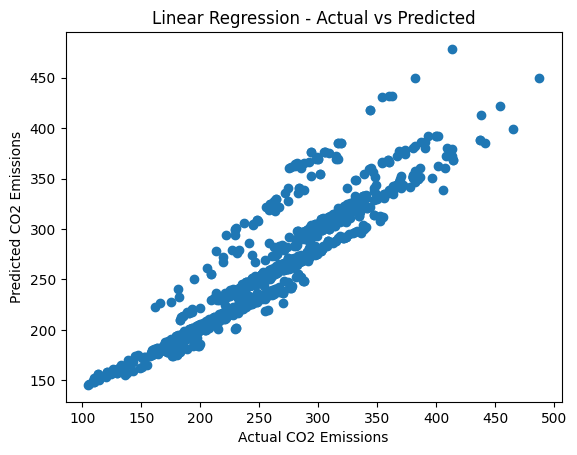

In [17]:
# =====================================
# STEP 12: Graph
# =====================================

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()